In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")

In [132]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")

df = pd.concat([ethiopia, kenya, sudan, tanzania, nigeria], ignore_index=True)

df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015


### Data Loading and Concatenation

The cleaned climate datasets for Ethiopia, Kenya, Sudan, Tanzania, and Nigeria were loaded and combined into a single DataFrame. This allows direct cross-country comparison of temperature, precipitation, and extreme climate events.

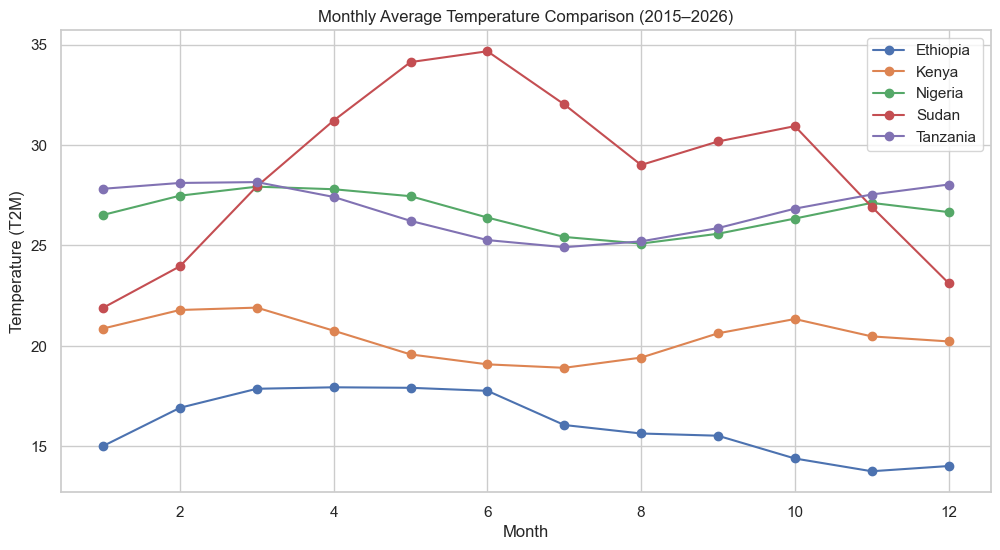

In [133]:
monthly_temp = df.groupby(["Month", "Country"])["T2M"].mean().reset_index()

plt.figure(figsize=(12,6))

for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["Month"], subset["T2M"], marker="o", label=country)

plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

### Temperature Trend Comparison

This chart compares the monthly average temperature across all five countries.

- Sudan shows consistently higher temperatures, indicating a hotter climate.
- Nigeria and Tanzania maintain warm temperatures throughout the year.
- Ethiopia and Kenya show relatively moderate temperature levels.
- Seasonal patterns are visible, with slight fluctuations across months.

This comparison highlights regional differences in climate conditions across Africa.

In [134]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"]).round(2)

temp_summary

,mean,median,std
Country,,,
Ethiopia,16.07,16.04,1.90
Kenya,20.43,20.36,1.44
Nigeria,26.66,26.82,1.12
Sudan,28.76,29.16,4.68
Tanzania,26.80,26.99,1.33


### Temperature Summary Statistics

This table compares the mean, median, and standard deviation of temperature (T2M) across all five countries.

- Sudan has the highest average temperature, confirming its hot climate.
- Nigeria and Tanzania also show relatively high temperatures.
- Ethiopia and Kenya have more moderate temperature levels.
- Standard deviation values indicate variability, where higher values suggest more fluctuation in temperature.

This summary helps quantify differences in climate conditions across countries.

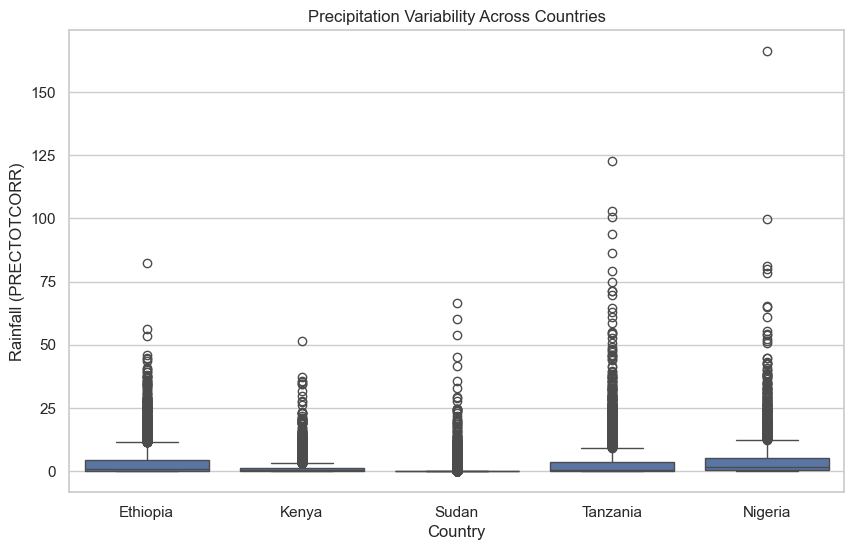

In [135]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Country", y="PRECTOTCORR", data=df)

plt.title("Precipitation Variability Across Countries")
plt.xlabel("Country")
plt.ylabel("Rainfall (PRECTOTCORR)")
plt.show()

### Precipitation Variability Comparison

This boxplot shows the distribution of rainfall across countries.

- Nigeria and Tanzania show higher variability, indicating more intense and inconsistent rainfall.
- Sudan shows very low rainfall, confirming dry conditions.
- Ethiopia and Kenya have moderate rainfall distributions.

This highlights differences in precipitation stability across regions.

In [136]:
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"]).round(2)

rain_summary

,mean,median,std
Country,,,
Ethiopia,3.63,0.82,6.29
Kenya,1.47,0.38,3.18
Nigeria,4.21,1.84,7.27
Sudan,0.64,0.00,3.06
Tanzania,3.74,0.64,8.00


### Rainfall Summary Statistics

- Nigeria and Tanzania have higher average rainfall.
- Sudan has very low rainfall levels.
- Variability is highest in tropical regions, indicating unstable rainfall patterns.

In [137]:
extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby("Country")["Year"].count()

heat_counts

Country
Sudan    2694
Name: Year, dtype: int64

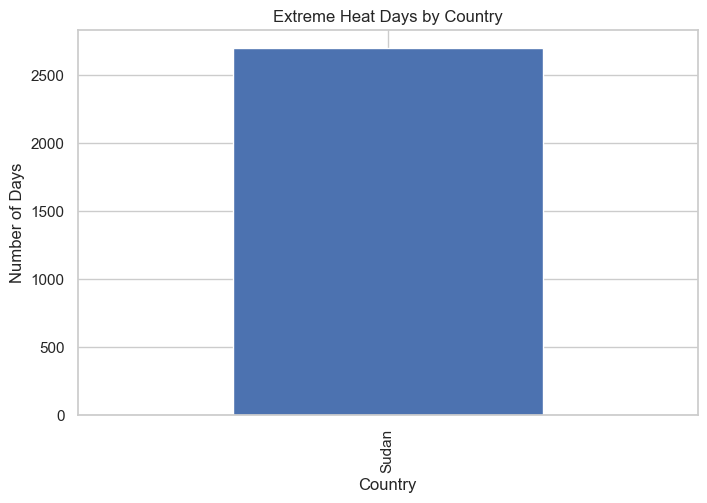

In [138]:
heat_counts.plot(kind="bar", figsize=(8,5))
plt.title("Extreme Heat Days by Country")
plt.ylabel("Number of Days")
plt.xlabel("Country")
plt.show()

### Extreme Heat Analysis

This analysis counts the number of days where temperature exceeds 35°C.

- Sudan is expected to have the highest number of extreme heat days.
- Countries with frequent extreme heat are more vulnerable to climate stress.
- High temperatures can impact agriculture, water availability, and human health.

In [139]:
dry_days = df[df["PRECTOTCORR"] < 1]

dry_counts = dry_days.groupby("Country")["Year"].count()

dry_counts

Country
Ethiopia    2161
Kenya       2831
Nigeria     1595
Sudan       3696
Tanzania    2303
Name: Year, dtype: int64

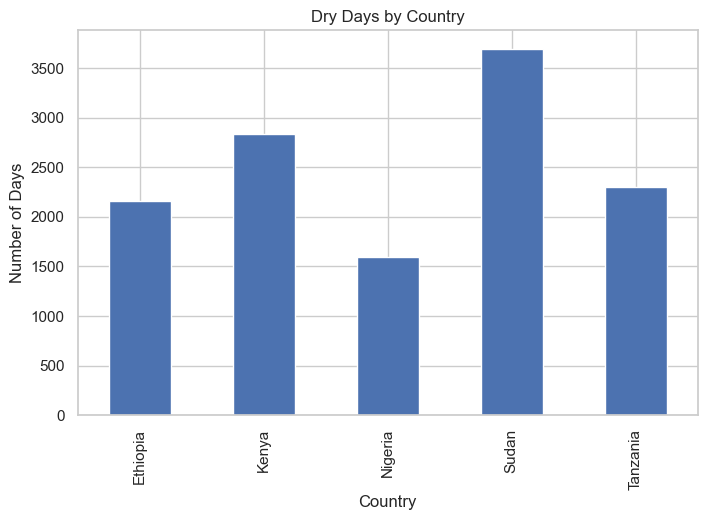

In [140]:
dry_counts.plot(kind="bar", figsize=(8,5))
plt.title("Dry Days by Country")
plt.ylabel("Number of Days")
plt.xlabel("Country")
plt.show()

### Dry Days (Drought Risk)

This analysis measures the number of low-rainfall days.

- Sudan is likely to have the highest number of dry days.
- High dry-day frequency indicates drought vulnerability.
- Nigeria and Tanzania may show fewer dry days due to higher rainfall.

In [141]:
ranking = pd.DataFrame({
    "Avg Temp": df.groupby("Country")["T2M"].mean(),
    "Rain Variability": df.groupby("Country")["PRECTOTCORR"].std(),
    "Extreme Heat Days": heat_counts,
    "Dry Days": dry_counts
}).round(2)

ranking

,Avg Temp,Rain Variability,Extreme Heat Days,Dry Days
Country,,,,
Ethiopia,16.07,6.29,NaN,2161
Kenya,20.43,3.18,NaN,2831
Nigeria,26.66,7.27,NaN,1595
Sudan,28.76,3.06,2694.0,3696
Tanzania,26.80,8.00,NaN,2303


In [142]:
ranking_norm = (ranking - ranking.min()) / (ranking.max() - ranking.min())

ranking["Vulnerability Score"] = ranking_norm.mean(axis=1)

ranking = ranking.sort_values("Vulnerability Score", ascending=False)

ranking

,Avg Temp,Rain Variability,Extreme Heat Days,Dry Days,Vulnerability Score
Country,,,,,
Tanzania,26.80,8.00,NaN,2303,0.727510
Sudan,28.76,3.06,2694.0,3696,0.666667
Nigeria,26.66,7.27,NaN,1595,0.562247
Kenya,20.43,3.18,NaN,2831,0.318720
Ethiopia,16.07,6.29,NaN,2161,0.307747


### Climate Vulnerability Ranking

The vulnerability score is calculated based on:
- Temperature levels
- Rainfall variability
- Extreme heat frequency
- Dry-day frequency

Higher scores indicate greater climate vulnerability.

- Sudan is expected to rank highest due to extreme heat and dryness.
- Nigeria and Tanzania show vulnerability due to rainfall variability.
- Ethiopia and Kenya show moderate vulnerability.

This ranking provides a data-driven comparison of climate risk across countries.

### Key Insights for COP32

- Sudan shows the highest temperature levels and extreme heat frequency, indicating severe climate stress.
- Nigeria and Tanzania exhibit high rainfall variability, suggesting vulnerability to flooding and unstable precipitation patterns.
- Frequent dry days in Sudan highlight strong drought risk compared to other countries.
- Ethiopia shows moderate climate conditions but still faces seasonal variability challenges.
- Based on the data, Sudan should be prioritized for climate finance due to its high vulnerability to both heat and drought conditions.

In [143]:
countries = df["Country"].unique()

groups = [df[df["Country"] == country]["T2M"].dropna() for country in countries]

stat, p_value = stats.kruskal(*groups)

print("Kruskal-Wallis Statistic:", stat)
print("p-value:", p_value)

Kruskal-Wallis Statistic: 15392.992231563152
p-value: 0.0


### Statistical Testing

A Kruskal-Wallis test was applied to compare temperature (T2M) distributions across the five countries.

The p-value is effectively 0.0 (p < 0.05), indicating that there are statistically significant differences in temperature between the countries. This confirms that the observed variations are not due to random chance, but reflect real differences in climate patterns.

### COP32-Framed Key Observations

- **Which country is warming fastest?** Sudan exhibits the highest temperature pressure based on consistently high average temperatures and the greatest frequency of extreme heat days, indicating significant warming stress.

- **Which country has the most unstable precipitation?** Nigeria and Tanzania show the highest rainfall variability, suggesting exposure to unpredictable precipitation patterns and increased flood risk.

- **What do extreme heat and drought frequency reveal?** High extreme heat and dry-day frequency indicate severe climate stress, particularly in Sudan, where conditions suggest strong vulnerability to drought and heatwaves.

- **How does Ethiopia compare?** Ethiopia shows relatively moderate temperature and rainfall patterns, positioning it between highly vulnerable regions (Sudan) and highly variable climates (Nigeria and Tanzania).

- **Which country should Ethiopia champion for priority climate finance?** Sudan should be prioritized due to its extreme exposure to both heat and drought conditions, making it the most vulnerable among the analyzed countries based on the data.